# 07 - Physical activity analysis

Notes:
- Not all PWE seqn appear to have PAX. Need to check how many people 

In [ ]:
# Record what this notebook ran against: commit, machine, data location.
# Rerun this cell before saving, so the saved outputs carry their provenance.
from ambient_light_epilepsy import provenance

provenance.describe()

In [16]:
from pathlib import Path
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import pyreadstat
import matplotlib.pyplot as plt
import seaborn as sns

import pyarrow.dataset as ds


from ambient_light_epilepsy import paths, provenance
import ambient_light_epilepsy.nhanes as nhn
import ambient_light_epilepsy.cohort as ch
import ambient_light_epilepsy.lux_metrics as lm
import time

In [27]:
def preprocess_ind_paxmin(df,
                         valid_seconds_threshold=45,
                         min_block_length=1440):
    """
    Preprocess a single participant PAXMIN dataframe.

    Parameters
    ----------
    df : pandas.DataFrame
        Raw dataframe from table.to_pandas()
    valid_seconds_threshold : int
        Threshold for valid seconds to define non-wear
    min_block_length : int
        Minimum length (minutes) for a valid wear block

    Returns
    -------
    df : pandas.DataFrame
        Full dataframe with time, wear flags, activity
    wear_df : pandas.DataFrame
        Dataframe restricted to valid wear blocks
    block_lengths : pandas.Series
        Length of each wear block
    """

    df = df.copy()

    # --- Time construction ---
    df["t"] = df["PAXSSNMP"] / (60 * 80)

    if not df["t"].is_monotonic_increasing:
        df["t"] = np.arange(len(df))

    # Minute of day (circadian phase)
    df["minute_of_day"] = df["t"] % 1440

    # --- Non-wear definition ---
    df["non_wear"] = (df["PAXTSM"] < valid_seconds_threshold) | (df["PAXPREDM"] == 3)

    # --- Wear block segmentation ---
    df["wear_block"] = (~df["non_wear"]).astype(int).diff().fillna(0).ne(0).cumsum()

    # --- Extract wear periods ---
    wear_df = df[~df["non_wear"]].copy()

    # --- Define activity  and lux (mask non-wear)  
    df["activity"] = df["PAXMTSM"].where(~df["non_wear"], np.nan)
    df["lux"] = df["PAXLXMM"].where(~df["non_wear"], np.nan)

    # --- Compute block lengths ---
    if len(wear_df) > 0:
        block_lengths = wear_df.groupby("wear_block").size()

        # Keep only sufficiently long blocks
        valid_blocks = block_lengths[block_lengths > min_block_length].index
        wear_df = wear_df[wear_df["wear_block"].isin(valid_blocks)]

        block_lengths = block_lengths.loc[valid_blocks]
    else:
        block_lengths = pd.Series(dtype=float)

    return df, wear_df, block_lengths

In [60]:
# Load a single PWE participant
base_path = paths.data_root()
seqn = ch.load_pwe_seqn("G", base_path)["SEQN"].to_list()[99] # seqn = 67908 is good for broken wear 
print(seqn)

# Load data into a pyarrow.dataset
dataset = ds.dataset(str(paths.raw_table("G", "PAXMIN")))

# Load relvent columns and rows from dataset
table = dataset.to_table(
    filter = ds.field("SEQN").isin([seqn]), # load specific SEQN only
    columns = ["SEQN", "PAXSSNMP", "PAXDAYM", "PAXDAYWM", "PAXPREDM", "PAXTSM", "PAXMTSM", "PAXLXMM"]
)

# Create a dataframe 
df = table.to_pandas()
df = df.astype(float) 

# Perform preprocessing
df, wear_df, block_lengths = preprocess_ind_paxmin(df)

# Calculate the total wear time
wear_mins = df["activity"].notna().sum()
print(f"Total wear mins: {wear_mins}")

70458.0
Total wear mins: 10957


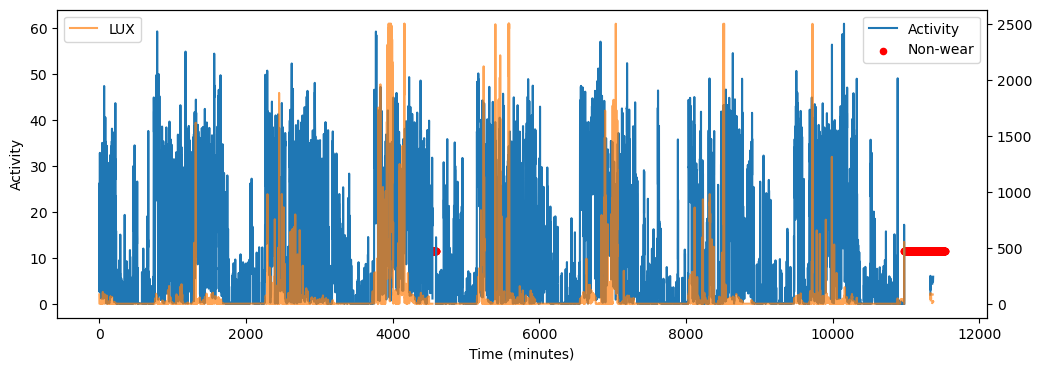

In [61]:
# Plot activity trace
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(df["t"], df["activity"], label='Activity')
ax.set_xlabel("Time (minutes)")
ax.set_ylabel("Activity")

# Plot non-wear time 
ax.scatter(df["t"][df["non_wear"]>0], df['activity'].mean()*df["non_wear"][df["non_wear"]>0], s=20, color='r', label='Non-wear')
#ax.vlines(df[df["wear_block"].diff()==1]['t'].values, 0, 80, color='C1', label='Wear transitions')
ax.legend()


ax1 = plt.twinx(ax)
ax1.plot(df["t"], df["lux"], color='C1', alpha=0.7, label='LUX')
ax1.legend(loc='upper left')


In [6]:
# table = dataset.to_table(
#             filter = ds.field("SEQN").isin([seqn]),
#             columns = ["SEQN", "PAXSSNMP", "PAXDAYM", "PAXDAYWM", "PAXPREDM", "PAXTSM", "PAXMTSM"]
#         )


# df = table.to_pandas()
# df = df.astype(float) 

# # --- Preprocess ---
# df, wear_df, block_lengths = preprocess_ind_paxmin(
#     df,
#     valid_seconds_threshold=45,
#     min_block_length=1440
# )

# total_minutes = len(df)
# total_wear_minutes = df["activity"].notna().sum()
# print(total_wear_minutes)

In [7]:
def preprocess_summary(seqn, dataset, group, year,
                               valid_seconds_threshold=45,
                               min_block_length=1440):

    # # Load relvent columns and rows from dataset
    # table = dataset.to_table(
    #     filter = ds.field("SEQN").isin([seqn]), # load specific SEQN only
    #     columns = ["SEQN", "PAXSSNMP", "PAXDAYM", "PAXDAYWM", "PAXPREDM", "PAXTSM", "PAXMTSM"]
    # )
    
    # # Create a dataframe 
    # df = table.to_pandas()
    # df = df.astype(float) 

    try:
        table = dataset.to_table(
            filter = ds.field("SEQN").isin([seqn]),
            columns = ["SEQN", "PAXSSNMP", "PAXDAYM", "PAXDAYWM", "PAXPREDM", "PAXTSM", "PAXMTSM"]
        )

        if table.num_rows == 0:
            raise ValueError("Empty table")

        df = table.to_pandas()
        df = df.astype(float) 
        

        # --- Preprocess ---
        df, wear_df, block_lengths = preprocess_ind_paxmin(
            df,
            valid_seconds_threshold=valid_seconds_threshold,
            min_block_length=min_block_length
        )

        total_minutes = len(df)
        total_wear_minutes = df["activity"].notna().sum()

        if len(block_lengths) > 0:
            summary = {
                "SEQN": seqn,
                "group": group,
                "year": year,
                "total_minutes": total_minutes,
                "total_wear_minutes": total_wear_minutes,
                "percent_wear": total_wear_minutes / total_minutes,
                "n_wear_blocks": len(block_lengths),
                "mean_block_length": block_lengths.mean(),
                "max_block_length": block_lengths.max()
            }

            blocks_df = pd.DataFrame({
                "SEQN": seqn,
                "group": group,
                "year": year,
                "block_length": block_lengths.values
            })

        else:
            summary = {
                "SEQN": seqn,
                "group": group,
                "year": year,
                "total_minutes": total_minutes,
                "total_wear_minutes": total_wear_minutes,
                "percent_wear": total_wear_minutes / total_minutes,
                "n_wear_blocks": 0,
                "mean_block_length": np.nan,
                "max_block_length": np.nan
            }

            blocks_df = None

        return summary, blocks_df

    except Exception:
        return {
            "SEQN": seqn,
            "group": group,
            "year": year,
            "total_minutes": np.nan,
            "total_wear_minutes": np.nan,
            "percent_wear": np.nan,
            "n_wear_blocks": np.nan,
            "mean_block_length": np.nan,
            "max_block_length": np.nan
        }, None

In [8]:
year = "G"

summaries = []
all_blocks = []
for year in ["G", "H"]:

    # Load the year-specific PAXMIN data
    dataset = ds.dataset(str(paths.raw_table(year, "PAXMIN")))
    
    # Load the year-specific SEQN numbers for PWE and controls
    control_seqns, pwe_seqns = ch.load_freq_matched_control_groups(year, base_path)
    
    # Loop through SEQNs. Store summaries and wear blocks
    # --- PWE ---
    for seqn in pwe_seqns:
        summary, blocks = preprocess_summary(seqn, dataset, "PWE", year)
        summaries.append(summary)
        if blocks is not None:
            all_blocks.append(blocks)
    
    # --- Controls ---
    for seqn in control_seqns:
        summary, blocks = preprocess_summary(seqn, dataset, "control", year)
        summaries.append(summary)
        if blocks is not None:
            all_blocks.append(blocks)



summary_df = pd.DataFrame(summaries)

if len(all_blocks) > 0:
    blocks_df = pd.concat(all_blocks, ignore_index=True)
else:
    blocks_df = pd.DataFrame()

In [9]:
blocks_df

,SEQN,group,year,block_length
0,62218,PWE,G,4476
1,62218,PWE,G,3494
2,62282,PWE,G,3327
3,62282,PWE,G,3771
4,62282,PWE,G,1677
...,...,...,...,...
642,76849,control,H,8520
643,76353,control,H,11028
644,73722,control,H,11103
645,76530,control,H,10895


In [10]:
summary_df

,SEQN,group,year,total_minutes,total_wear_minutes,percent_wear,n_wear_blocks,mean_block_length,max_block_length
0,62218,PWE,G,11530.0,8213.0,0.712316,2.0,3985.0,4476.0
1,62282,PWE,G,11530.0,9194.0,0.797398,3.0,2925.0,3771.0
2,62293,PWE,G,11529.0,8637.0,0.749154,1.0,8637.0,8637.0
3,62307,PWE,G,11530.0,11512.0,0.998439,1.0,11511.0,11511.0
4,62370,PWE,G,11529.0,11416.0,0.990199,1.0,11415.0,11415.0
...,...,...,...,...,...,...,...,...,...
856,81103,control,H,NaN,NaN,NaN,NaN,NaN,NaN
857,81997,control,H,NaN,NaN,NaN,NaN,NaN,NaN
858,78899,control,H,NaN,NaN,NaN,NaN,NaN,NaN
859,76531,control,H,11529.0,11216.0,0.972851,1.0,11209.0,11209.0


In [11]:
display(summary_df)
print(f"Total number of participants: {len(control_seqns) + len(pwe_seqns)}")

,SEQN,group,year,total_minutes,total_wear_minutes,percent_wear,n_wear_blocks,mean_block_length,max_block_length
0,62218,PWE,G,11530.0,8213.0,0.712316,2.0,3985.0,4476.0
1,62282,PWE,G,11530.0,9194.0,0.797398,3.0,2925.0,3771.0
2,62293,PWE,G,11529.0,8637.0,0.749154,1.0,8637.0,8637.0
3,62307,PWE,G,11530.0,11512.0,0.998439,1.0,11511.0,11511.0
4,62370,PWE,G,11529.0,11416.0,0.990199,1.0,11415.0,11415.0
...,...,...,...,...,...,...,...,...,...
856,81103,control,H,NaN,NaN,NaN,NaN,NaN,NaN
857,81997,control,H,NaN,NaN,NaN,NaN,NaN,NaN
858,78899,control,H,NaN,NaN,NaN,NaN,NaN,NaN
859,76531,control,H,11529.0,11216.0,0.972851,1.0,11209.0,11209.0


Total number of participants: 503


Text(0.5, 1.0, 'Mean wear block length per participant')

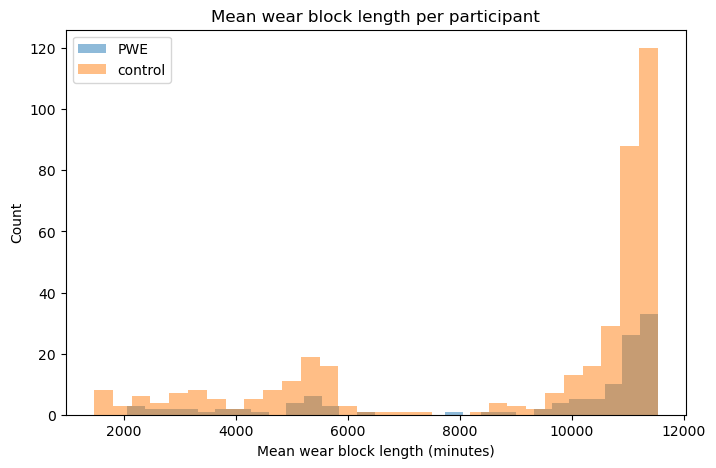

In [12]:
plt.figure(figsize=(8,5))

for group in ["PWE", "control"]:
    subset = summary_df[summary_df["group"] == group]
    plt.hist(subset["mean_block_length"].dropna(), bins=30, alpha=0.5, label=group)

plt.xlabel("Mean wear block length (minutes)")
plt.ylabel("Count")
plt.legend()
plt.title("Mean wear block length per participant")

In [13]:
def summarise_paxmin_availability(summary_df,
                                 wear_threshold_minutes=1000):
    """
    Summarise PAXMIN data availability by group.

    Parameters
    ----------
    summary_df : pandas.DataFrame
        Output from cohort loop
    wear_threshold_minutes : int
        Threshold to define 'usable' data

    Returns
    -------
    summary_table : pandas.DataFrame
    """

    results = []

    for group in summary_df["group"].unique():
        df_g = summary_df[summary_df["group"] == group]

        total = len(df_g)

        # Has any PAXMIN file (i.e. not NaN total_minutes)
        has_file = df_g["total_minutes"].notna().sum()

        # Missing file
        missing_file = df_g["total_minutes"].isna().sum()

        # Has some wear data
        has_wear = (df_g["total_wear_minutes"] > 0).sum()

        # Usable data (you can tune this threshold)
        usable = (df_g["total_wear_minutes"] > wear_threshold_minutes).sum()

        results.append({
            "group": group,
            "n_total": total,
            "n_with_file": has_file,
            "n_missing_file": missing_file,
            "n_with_any_wear": has_wear,
            "n_usable": usable,
            "pct_with_file": has_file / total,
            "pct_usable": usable / total
        })

    return pd.DataFrame(results)

summarise_paxmin_availability(summary_df,
                                 wear_threshold_minutes=1000)

,group,n_total,n_with_file,n_missing_file,n_with_any_wear,n_usable,pct_with_file,pct_usable
0,PWE,192,122,70,122,122,0.635417,0.635417
1,control,669,406,263,406,403,0.606876,0.602392


In [14]:
summary_df_h = summary_df[summary_df['year']=='H']
summary_df_g = summary_df[summary_df['year']=='G']

summarise_paxmin_availability(summary_df_h,
                                 wear_threshold_minutes=1000)

,group,n_total,n_with_file,n_missing_file,n_with_any_wear,n_usable,pct_with_file,pct_usable
0,PWE,110,40,70,40,40,0.363636,0.363636
1,control,393,130,263,130,130,0.330789,0.330789


In [15]:
summarise_paxmin_availability(summary_df_g,
                                 wear_threshold_minutes=1000)

,group,n_total,n_with_file,n_missing_file,n_with_any_wear,n_usable,pct_with_file,pct_usable
0,PWE,82,82,0,82,82,1.0,1.00000
1,control,276,276,0,276,273,1.0,0.98913


- seems like there is a large number of ppl in the H cohort that have missing PAX data. this could be valid, or it could be due to poor PAXMIN_H download. G data looks fine though. weird to have big difference between cohorts. 
- to check: see how many H ppl have valid LUX data, as the PAX and LUX come from the same device
- also, shouldnt I do the same preprocessing steps to the LUX data that i do to the PAX data? there will be same fragmentation and non-wear issues.